# Import Libraries

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not found")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not found — pip install shap")

# Load Dataset

In [2]:
data = pd.read_csv("C:/Users/anike/Desktop/Project/Enterprice fraud Detection_ML/enterprise_fraud_dataset.csv")

# Data Overview

In [3]:
data

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,...,20,5.035833e+05,426.455356,0.9937,-1,0,4,0,legit,0.0
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,...,16,1.607163e+06,298.932645,0.2719,-1,0,1,0,legit,0.0
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,...,17,1.702030e+05,502.709227,0.6882,-1,2,1,0,legit,0.0
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,...,17,1.076657e+04,320.324984,0.8116,13,0,3,0,legit,0.0
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,...,14,2.087674e+06,183.407743,0.7762,13,1,4,0,legit,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,TXN00057042,10625,1652,2025-02-04 00:57:39.212327989,0,35,1,0,1,regular,...,17,2.109112e+06,101.296190,0.8806,-1,0,2,0,legit,0.0
199996,TXN00167080,1975,750,2025-04-10 11:24:24.500505749,11,100,3,0,0,regular,...,15,9.999900e+04,635.595542,1.2133,-1,0,4,0,legit,0.0
199997,TXN00177337,5139,1591,2025-04-16 13:21:58.135764942,13,106,2,0,0,regular,...,19,5.796304e+05,83.981791,0.9933,-1,0,2,0,legit,0.0
199998,TXN00023587,11129,1588,2025-01-15 02:59:47.294468908,2,15,2,0,1,regular,...,19,8.467141e+05,375.150639,1.6644,-1,0,1,0,legit,0.0


In [4]:
data.head()

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,...,20,5.035833e+05,426.455356,0.9937,-1,0,4,0,legit,0.0
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,...,16,1.607163e+06,298.932645,0.2719,-1,0,1,0,legit,0.0
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,...,17,1.702030e+05,502.709227,0.6882,-1,2,1,0,legit,0.0
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,...,17,1.076657e+04,320.324984,0.8116,13,0,3,0,legit,0.0
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,...,14,2.087674e+06,183.407743,0.7762,13,1,4,0,legit,0.0


In [5]:
data.tail()

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
199995,TXN00057042,10625,1652,2025-02-04 00:57:39.212327989,0,35,1,0,1,regular,...,17,2.109112e+06,101.296190,0.8806,-1,0,2,0,legit,0.0
199996,TXN00167080,1975,750,2025-04-10 11:24:24.500505749,11,100,3,0,0,regular,...,15,9.999900e+04,635.595542,1.2133,-1,0,4,0,legit,0.0
199997,TXN00177337,5139,1591,2025-04-16 13:21:58.135764942,13,106,2,0,0,regular,...,19,5.796304e+05,83.981791,0.9933,-1,0,2,0,legit,0.0
199998,TXN00023587,11129,1588,2025-01-15 02:59:47.294468908,2,15,2,0,1,regular,...,19,8.467141e+05,375.150639,1.6644,-1,0,1,0,legit,0.0
199999,TXN00160385,7295,1527,2025-04-06 11:08:45.194856544,11,96,6,1,0,new,...,22,1.100385e+06,474.456160,1.7009,2,0,2,0,legit,0.0


In [6]:
data.describe()

,customer_id,merchant_id,hour,day,weekday,is_weekend,is_night,avg_spend_profile,home_lat,home_lon,...,transaction_velocity_24h,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,financial_loss
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,2.000000e+05,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,7014.387470,1249.318520,11.502865,60.057440,3.003220,0.286665,0.251455,302.404364,26.987620,31.007323,...,4.666430,17.999935,5.454340e+05,302.311520,1.199390,-0.572745,0.325665,3.006005,0.027815,25.367445
std,3463.076696,433.370543,6.933621,34.329666,2.001634,0.452205,0.433851,214.181119,2.897108,3.451591,...,3.242398,4.233868,5.677621e+05,218.644949,0.839650,2.081961,0.672361,1.737212,0.164443,243.859942
min,1000.000000,500.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.828483,22.000167,25.000101,...,0.000000,2.000000,1.039357e+00,0.692228,0.000800,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,4025.000000,873.000000,5.000000,30.000000,1.000000,0.000000,0.000000,144.058671,24.453278,28.083762,...,3.000000,15.000000,1.277212e+05,142.425808,0.710100,-1.000000,0.000000,2.000000,0.000000,0.000000
50%,7021.000000,1250.000000,12.000000,60.000000,3.000000,0.000000,0.000000,253.859201,26.972758,30.987583,...,4.000000,18.000000,3.632285e+05,250.476673,1.010700,-1.000000,0.000000,3.000000,0.000000,0.000000
75%,10018.000000,1626.000000,18.000000,90.000000,5.000000,1.000000,1.000000,408.153275,29.517155,33.999560,...,6.000000,21.000000,7.601484e+05,405.942969,1.448325,-1.000000,1.000000,4.000000,0.000000,0.000000
max,12999.000000,1999.000000,23.000000,119.000000,6.000000,1.000000,1.000000,2054.198815,31.999721,36.999276,...,59.000000,42.000000,7.330058e+06,2439.965571,23.681500,14.000000,11.000000,14.000000,1.000000,14027.390000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               200000 non-null  object 
 1   customer_id                  200000 non-null  int64  
 2   merchant_id                  200000 non-null  int64  
 3   timestamp                    200000 non-null  object 
 4   hour                         200000 non-null  int64  
 5   day                          200000 non-null  int64  
 6   weekday                      200000 non-null  int64  
 7   is_weekend                   200000 non-null  int64  
 8   is_night                     200000 non-null  int64  
 9   customer_segment             200000 non-null  object 
 10  avg_spend_profile            200000 non-null  float64
 11  home_lat                     200000 non-null  float64
 12  home_lon                     200000 non-null  float64
 13 

In [8]:
data.columns

Index(['transaction_id', 'customer_id', 'merchant_id', 'timestamp', 'hour',
       'day', 'weekday', 'is_weekend', 'is_night', 'customer_segment',
       'avg_spend_profile', 'home_lat', 'home_lon', 'past_fraud_history',
       'credit_score', 'account_age_days', 'merchant_category',
       'merchant_risk_score', 'merchant_lat', 'merchant_lon',
       'transaction_amount', 'txn_lat', 'txn_lon', 'distance_from_home_km',
       'is_foreign', 'high_risk_country', 'device_type', 'channel',
       'is_new_device', 'vpn_detected', 'tor_detected', 'device_id',
       'transaction_velocity_1h', 'transaction_velocity_24h',
       'transaction_velocity_7d', 'seconds_since_last_txn', 'avg_amount_30d',
       'amount_deviation_ratio', 'merchant_ring_id', 'shared_device_count',
       'customer_merchant_txn_count', 'label', 'fraud_type', 'financial_loss'],
      dtype='object')

In [9]:
data.shape

(200000, 44)

In [10]:
data.isnull().sum()

transaction_id                 0
customer_id                    0
merchant_id                    0
timestamp                      0
hour                           0
day                            0
weekday                        0
is_weekend                     0
is_night                       0
customer_segment               0
avg_spend_profile              0
home_lat                       0
home_lon                       0
past_fraud_history             0
credit_score                   0
account_age_days               0
merchant_category              0
merchant_risk_score            0
merchant_lat                   0
merchant_lon                   0
transaction_amount             0
txn_lat                        0
txn_lon                        0
distance_from_home_km          0
is_foreign                     0
high_risk_country              0
device_type                    0
channel                        0
is_new_device                  0
vpn_detected                   0
tor_detect

In [11]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [12]:
print(f"Fraud Rate : {data['label'].mean():.2%}")

Fraud Rate : 2.78%


# EDA

## Class Imbalance

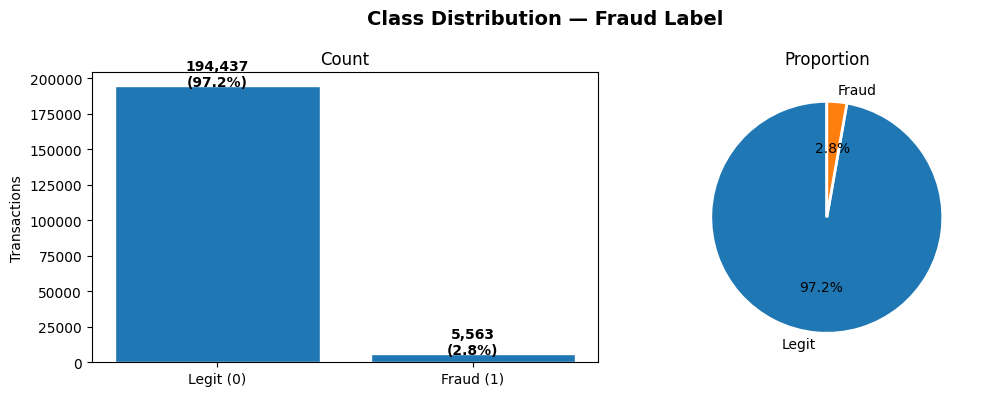

In [13]:
counts = data["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Class Distribution — Fraud Label", fontsize=14, fontweight="bold")

axes[0].bar(["Legit (0)", "Fraud (1)"], counts.values, edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(data)*100:.1f}%)",
                 ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Count")
axes[0].set_ylabel("Transactions")

axes[1].pie(counts.values, labels=["Legit", "Fraud"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proportion")
plt.tight_layout()
plt.show()

## Transaction Amount Distribution


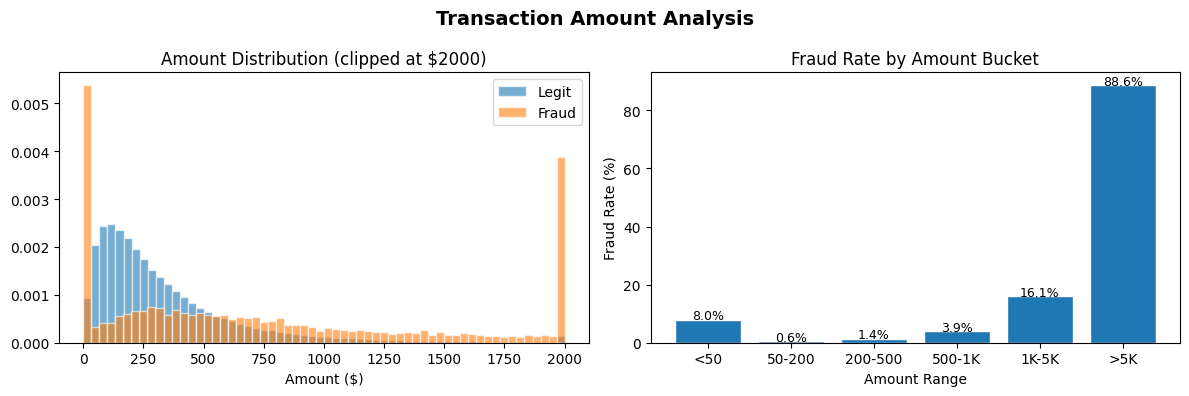

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Transaction Amount Analysis", fontsize=14, fontweight="bold")

for lbl, name in [(0, "Legit"), (1, "Fraud")]:
    axes[0].hist(data[data["label"] == lbl]["transaction_amount"].clip(0, 2000),
                 bins=60, alpha=0.6, label=name, density=True, edgecolor="white")
axes[0].set_title("Amount Distribution (clipped at $2000)")
axes[0].set_xlabel("Amount ($)")
axes[0].legend()

amount_bins = pd.cut(data["transaction_amount"],
                     bins=[0, 50, 200, 500, 1000, 5000, np.inf],
                     labels=["<50", "50-200", "200-500", "500-1K", "1K-5K", ">5K"])
rate = data.groupby(amount_bins, observed=True)["label"].mean() * 100
axes[1].bar(rate.index, rate.values, edgecolor="white")
axes[1].set_title("Fraud Rate by Amount Bucket")
axes[1].set_xlabel("Amount Range")
axes[1].set_ylabel("Fraud Rate (%)")
for i, v in enumerate(rate.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Categorical Features — Fraud Rate

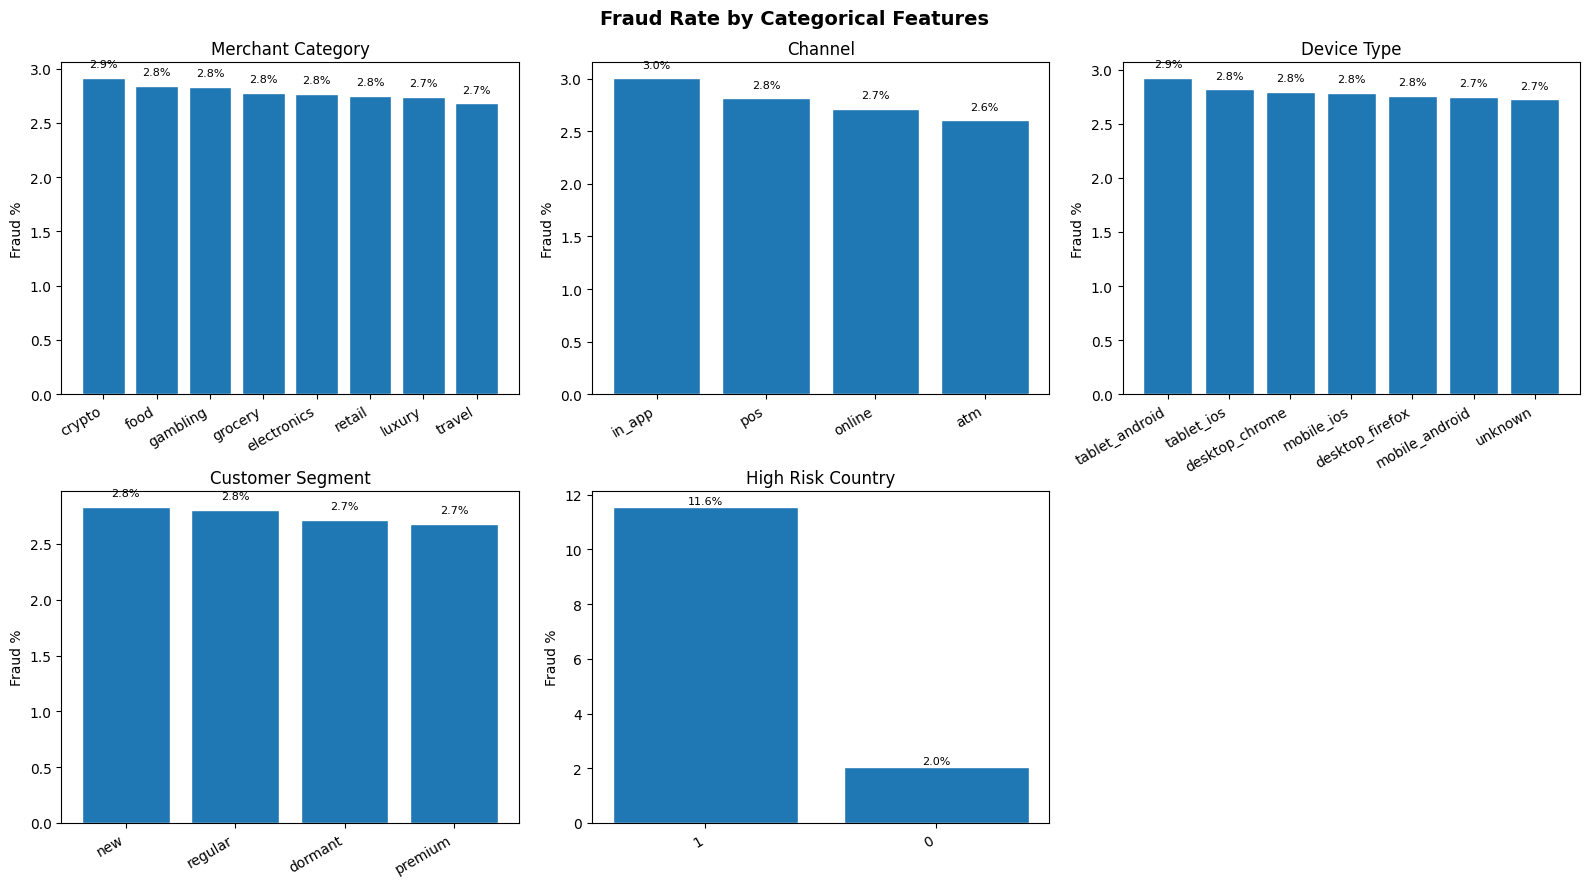

In [15]:
cat_cols = ["merchant_category", "channel", "device_type", "customer_segment", "high_risk_country"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Fraud Rate by Categorical Features", fontsize=14, fontweight="bold")
axes = axes.flatten()

for idx, col in enumerate(cat_cols):
    if col not in data.columns:
        axes[idx].set_visible(False)
        continue
    rate = data.groupby(col)["label"].mean().sort_values(ascending=False) * 100
    bars = axes[idx].bar(range(len(rate)), rate.values, edgecolor="white")
    axes[idx].set_xticks(range(len(rate)))
    axes[idx].set_xticklabels(rate.index, rotation=30, ha="right")
    axes[idx].set_title(col.replace("_", " ").title())
    axes[idx].set_ylabel("Fraud %")
    for bar, val in zip(bars, rate.values):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, val + 0.1,
                       f"{val:.1f}%", ha="center", fontsize=8)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

## Velocity & Numerical Features

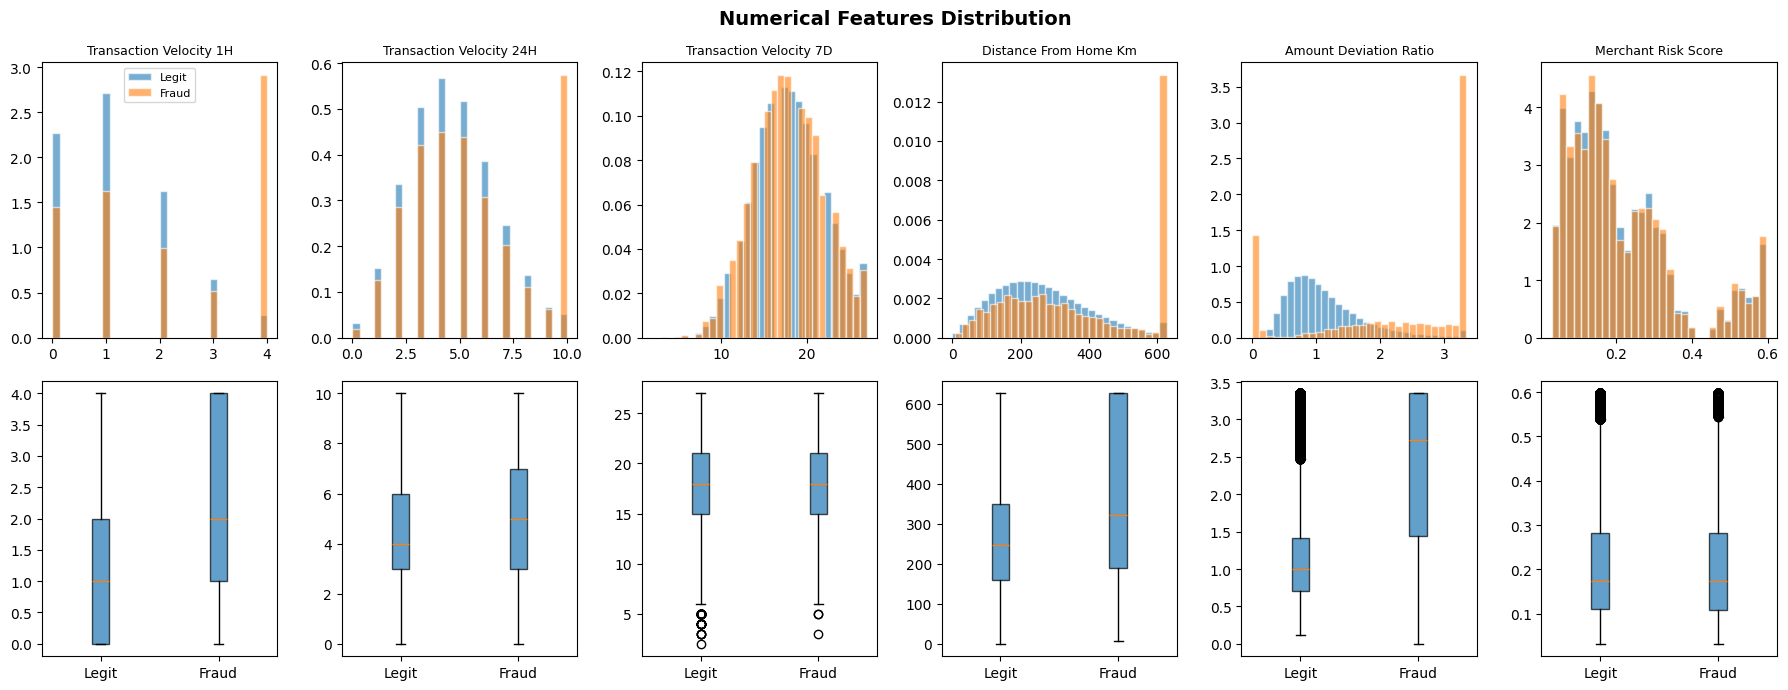

In [16]:
num_cols = ["transaction_velocity_1h", "transaction_velocity_24h",
            "transaction_velocity_7d", "distance_from_home_km",
            "amount_deviation_ratio", "merchant_risk_score"]
num_cols = [c for c in num_cols if c in data.columns]

fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 7))
fig.suptitle("Numerical Features Distribution", fontsize=14, fontweight="bold")

for i, col in enumerate(num_cols):
    clip_val = data[col].quantile(0.98)
    for lbl, name in [(0, "Legit"), (1, "Fraud")]:
        axes[0, i].hist(data[data["label"] == lbl][col].clip(0, clip_val),
                        bins=30, alpha=0.6, label=name, density=True, edgecolor="white")
    axes[0, i].set_title(col.replace("_", " ").title(), fontsize=9)
    if i == 0:
        axes[0, i].legend(fontsize=8)

    bp = axes[1, i].boxplot(
        [data[data["label"] == 0][col].clip(0, clip_val),
         data[data["label"] == 1][col].clip(0, clip_val)],
        patch_artist=True, labels=["Legit", "Fraud"]
    )
    for patch in bp["boxes"]:
        patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

## Fraud Rate by Hour of Day

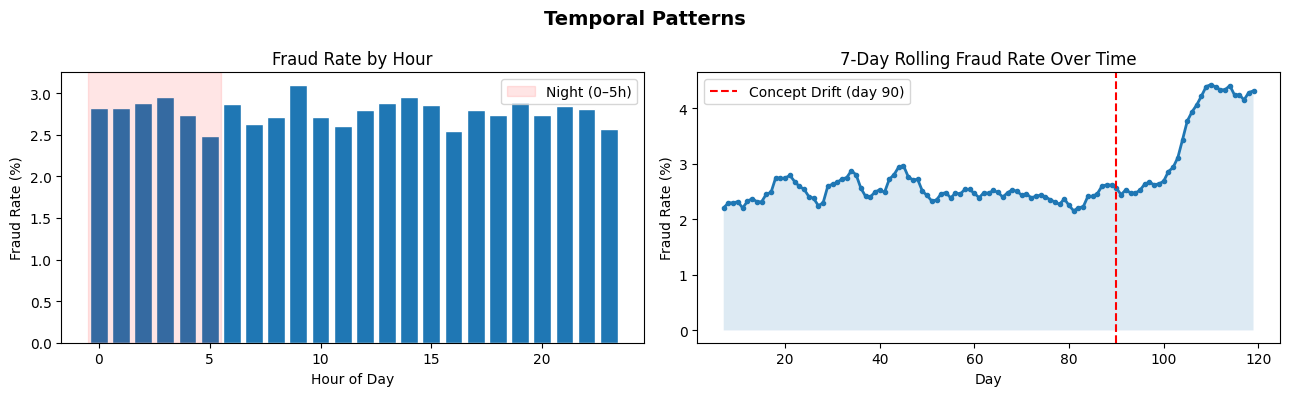

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Temporal Patterns", fontsize=14, fontweight="bold")

hourly = data.groupby("hour")["label"].mean() * 100
axes[0].bar(hourly.index, hourly.values, edgecolor="white")
axes[0].axvspan(-0.5, 5.5, alpha=0.1, color="red", label="Night (0–5h)")
axes[0].set_title("Fraud Rate by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].legend()

if "day" in data.columns:
    daily = data.groupby("day")["label"].mean().rolling(7).mean() * 100
    axes[1].plot(daily.index, daily.values, linewidth=2, marker="o", markersize=3)
    axes[1].fill_between(daily.index, daily.values, alpha=0.15)
    axes[1].axvline(90, color="red", lw=1.5, ls="--", label="Concept Drift (day 90)")
    axes[1].set_title("7-Day Rolling Fraud Rate Over Time")
    axes[1].set_xlabel("Day")
    axes[1].set_ylabel("Fraud Rate (%)")
    axes[1].legend()

plt.tight_layout()
plt.show()

## Correlation Heatmap

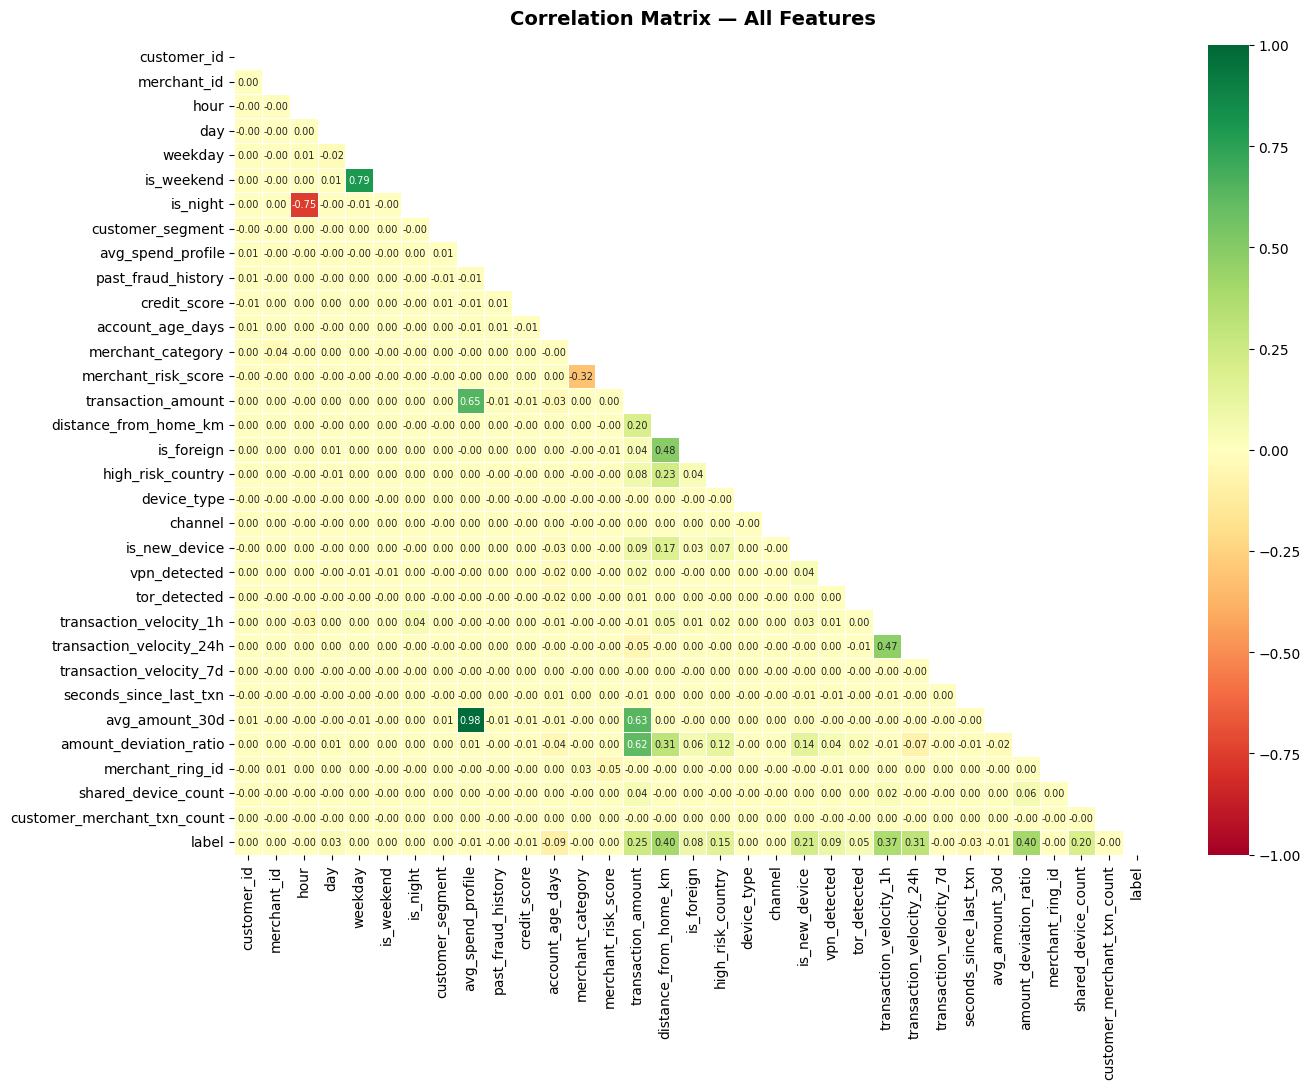

In [18]:
data_enc = data.copy()
le = LabelEncoder()
for col in data_enc.select_dtypes("object").columns:
    data_enc[col] = le.fit_transform(data_enc[col].astype(str))

drop_for_corr = ["transaction_id", "device_id", "timestamp", "fraud_type",
                 "financial_loss", "home_lat", "home_lon", "merchant_lat",
                 "merchant_lon", "txn_lat", "txn_lon"]
data_enc.drop(columns=[c for c in drop_for_corr if c in data_enc.columns], inplace=True)

corr = data_enc.corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor="white", annot_kws={"size": 7})
ax.set_title("Correlation Matrix — All Features", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

# Feature Engineering

In [19]:
data_ml = data_enc.copy()

# Velocity ratios
data_ml["vel_ratio_1h_24h"]  = data_ml["transaction_velocity_1h"]  / (data_ml["transaction_velocity_24h"] + 1)
data_ml["vel_ratio_24h_7d"]  = data_ml["transaction_velocity_24h"] / (data_ml["transaction_velocity_7d"]  + 1)

# Amount features
data_ml["amount_log"]        = np.log1p(data_ml["transaction_amount"])
data_ml["amount_bucket"]     = pd.qcut(data_ml["transaction_amount"], q=10, labels=False, duplicates="drop")

# Risk composite
risk_cols = {
    "merchant_risk_score": 0.35,
    "vpn_detected":        0.15,
    "tor_detected":        0.15,
    "is_new_device":       0.10,
    "high_risk_country":   0.10,
    "is_foreign":          0.10,
    "shared_device_count": 0.05,
}
data_ml["risk_composite"] = sum(
    data_ml[col] * w for col, w in risk_cols.items() if col in data_ml.columns
)

# Device anomaly score
device_flags = ["is_new_device", "vpn_detected", "tor_detected"]
data_ml["device_anomaly"] = data_ml[[c for c in device_flags if c in data_ml.columns]].sum(axis=1)

# Interaction features
if "credit_score" in data_ml.columns:
    data_ml["amount_x_risk"]       = data_ml["amount_log"] * data_ml["risk_composite"]
    data_ml["velocity_x_risk"]     = data_ml["transaction_velocity_1h"] * data_ml["risk_composite"]
    data_ml["low_credit_high_vel"] = ((data_ml["credit_score"] < 500) &
                                      (data_ml["transaction_velocity_1h"] > 3)).astype(int)

DROP_COLS = ["transaction_id", "device_id", "timestamp", "fraud_type",
             "financial_loss", "home_lat", "home_lon", "merchant_lat",
             "merchant_lon", "txn_lat", "txn_lon", "date"]
X = data_ml.drop(columns=["label"] + [c for c in DROP_COLS if c in data_ml.columns])
y = data_ml["label"]

print(f"Features after engineering: {X.shape[1]}")
print(f"Feature list: {list(X.columns)}")

Features after engineering: 41
Feature list: ['customer_id', 'merchant_id', 'hour', 'day', 'weekday', 'is_weekend', 'is_night', 'customer_segment', 'avg_spend_profile', 'past_fraud_history', 'credit_score', 'account_age_days', 'merchant_category', 'merchant_risk_score', 'transaction_amount', 'distance_from_home_km', 'is_foreign', 'high_risk_country', 'device_type', 'channel', 'is_new_device', 'vpn_detected', 'tor_detected', 'transaction_velocity_1h', 'transaction_velocity_24h', 'transaction_velocity_7d', 'seconds_since_last_txn', 'avg_amount_30d', 'amount_deviation_ratio', 'merchant_ring_id', 'shared_device_count', 'customer_merchant_txn_count', 'vel_ratio_1h_24h', 'vel_ratio_24h_7d', 'amount_log', 'amount_bucket', 'risk_composite', 'device_anomaly', 'amount_x_risk', 'velocity_x_risk', 'low_credit_high_vel']


# Train / Test Split (Time-Based)

In [20]:
if "day" in X.columns:
    split_day = int(data_ml["day"].quantile(0.8))
    train_mask = data_ml["day"] <= split_day
    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]
    print(f"Time-based split at day {split_day}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

sample_weights = compute_sample_weight("balanced", y_train)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train fraud: {y_train.mean():.2%}  |  Test fraud: {y_test.mean():.2%}")

Time-based split at day 96
Train: 161,238  |  Test: 38,762
Train fraud: 2.50%  |  Test fraud: 3.96%


# Model Training


In [21]:
models = {}

## XGBoost

In [22]:
if HAS_XGB:
    print("Training XGBoost")
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_clf = xgb.XGBClassifier(
        n_estimators         = 500,
        max_depth            = 6,
        learning_rate        = 0.05,
        subsample            = 0.8,
        colsample_bytree     = 0.8,
        min_child_weight     = 5,
        gamma                = 1,
        reg_alpha            = 0.1,
        reg_lambda           = 1.0,
        scale_pos_weight     = scale_pos,
        eval_metric          = "aucpr",
        early_stopping_rounds= 30,
        random_state         = 42,
        n_jobs               = -1,
        verbosity            = 0,
    )
    xgb_clf.fit(X_train, y_train,
                sample_weight=sample_weights,
                eval_set=[(X_test, y_test)],
                verbose=False)
    models["XGBoost"] = xgb_clf

Training XGBoost


## LightGBM

In [23]:
if HAS_LGB:
    print("Training LightGBM")
    lgb_clf = lgb.LGBMClassifier(
        n_estimators     = 500,
        max_depth        = 7,
        learning_rate    = 0.05,
        num_leaves       = 63,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_samples= 20,
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        is_unbalance     = True,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = -1,
    )
    lgb_clf.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                callbacks=[lgb.early_stopping(30, verbose=False),
                           lgb.log_evaluation(-1)])
    models["LightGBM"] = lgb_clf

Training LightGBM


## Logistic Regression

In [24]:
print("Training Logistic Regression")
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)
lr_clf      = LogisticRegression(max_iter=1000, class_weight="balanced",
                                  random_state=42, n_jobs=1)
lr_clf.fit(X_train_sc, y_train)
models["LogisticRegression"] = ("scaled", lr_clf)

Training Logistic Regression


## Random Forest

In [25]:
print("Training Random Forest")
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
models["RandomForest"] = rf_clf

Training Random Forest


# Evaluation

In [26]:
results = {}

for name, model in models.items():
    if isinstance(model, tuple):
        _, m   = model
        y_pred  = m.predict(X_test_sc)
        y_proba = m.predict_proba(X_test_sc)[:, 1]
    else:
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ap  = average_precision_score(y_test, y_proba)

    results[name] = {"Accuracy": acc, "F1": f1, "AUC": auc, "AP": ap,
                     "y_pred": y_pred, "y_proba": y_proba}
    print(f"\n{name}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"  Avg Prec  : {ap:.4f}")

# Best model
best_name  = max(results, key=lambda k: results[k]["AUC"])
best_res   = results[best_name]
best_model = models[best_name]
if isinstance(best_model, tuple):
    best_model = best_model[1]

print(f"\nBest Model: {best_name} (AUC = {best_res['AUC']:.4f})")


XGBoost
  Accuracy  : 0.9853
  F1 Score  : 0.7764
  AUC-ROC   : 0.9707
  Avg Prec  : 0.8475

LightGBM
  Accuracy  : 0.9839
  F1 Score  : 0.7601
  AUC-ROC   : 0.9628
  Avg Prec  : 0.8005

LogisticRegression
  Accuracy  : 0.9637
  F1 Score  : 0.6128
  AUC-ROC   : 0.9258
  Avg Prec  : 0.7394

RandomForest
  Accuracy  : 0.9851
  F1 Score  : 0.7714
  AUC-ROC   : 0.9658
  Avg Prec  : 0.8322

Best Model: XGBoost (AUC = 0.9707)


# Threshold Optimization

In [27]:
thresholds = np.linspace(0.1, 0.9, 200)
f1_scores  = [f1_score(y_test, (best_res["y_proba"] >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
best_pred   = (best_res["y_proba"] >= best_thresh).astype(int)

print(f"Optimal Threshold : {best_thresh:.3f}  (F1 = {max(f1_scores):.4f})")
print(f"\nClassification Report — {best_name} @ threshold {best_thresh:.2f}:")
print(classification_report(y_test, best_pred, target_names=["Legit", "Fraud"]))

Optimal Threshold : 0.281  (F1 = 0.7793)

Classification Report — XGBoost @ threshold 0.28:
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99     37227
       Fraud       0.97      0.65      0.78      1535

    accuracy                           0.99     38762
   macro avg       0.98      0.83      0.89     38762
weighted avg       0.99      0.99      0.98     38762



# Plots

## Model Comparison Bar

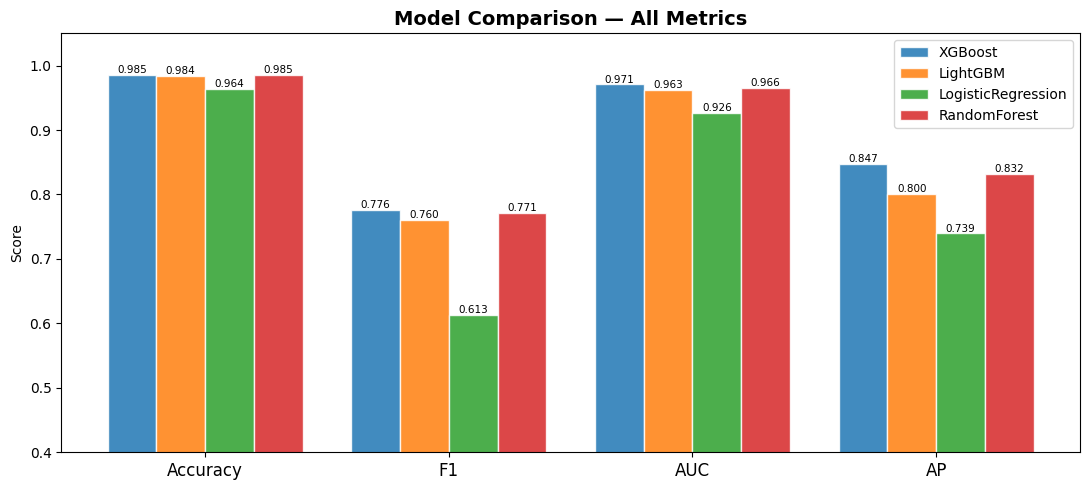

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
metrics     = ["Accuracy", "F1", "AUC", "AP"]
x           = np.arange(len(metrics))
width       = 0.2
model_names = list(results.keys())

for i, mname in enumerate(model_names):
    vals = [results[mname][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=mname,
                  edgecolor="white", alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                f"{v:.3f}", ha="center", fontsize=7.5)

ax.set_xticks(x + width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.4, 1.05)
ax.set_title("Model Comparison — All Metrics", fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## ROC Curves

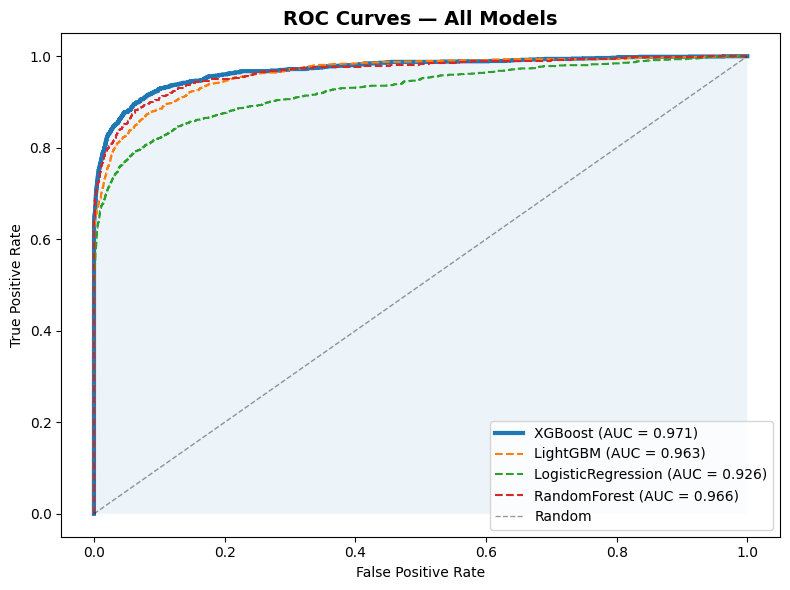

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
for mname, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    lw = 3 if mname == best_name else 1.5
    ls = "-" if mname == best_name else "--"
    ax.plot(fpr, tpr, linewidth=lw, linestyle=ls,
            label=f"{mname} (AUC = {res['AUC']:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random")
ax.fill_between(*roc_curve(y_test, best_res["y_proba"])[:2], alpha=0.08)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Precision-Recall Curves

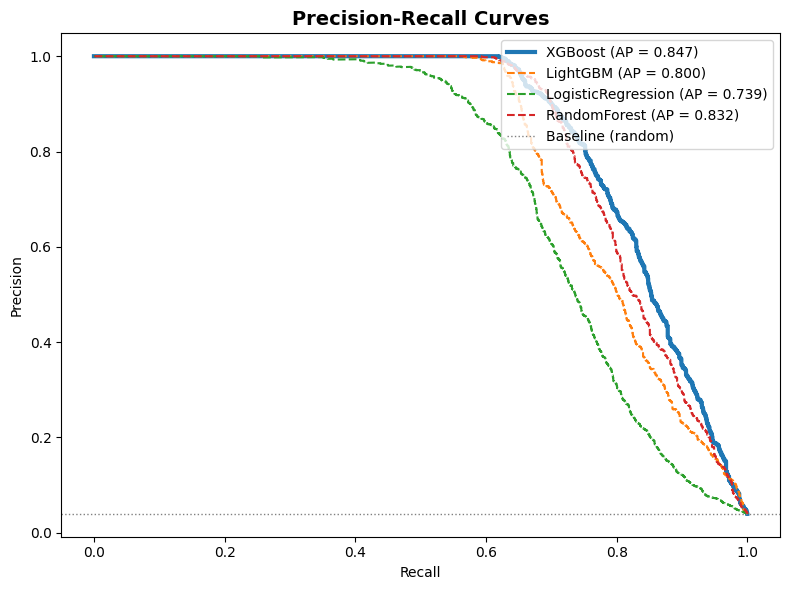

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))
for mname, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    lw = 3 if mname == best_name else 1.5
    ls = "-" if mname == best_name else "--"
    ax.plot(rec, prec, linewidth=lw, linestyle=ls,
            label=f"{mname} (AP = {res['AP']:.3f})")

ax.axhline(y_test.mean(), color="gray", lw=1, ls=":", label="Baseline (random)")
ax.set_title("Precision-Recall Curves", fontsize=14, fontweight="bold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Confusion Matrix (best model)

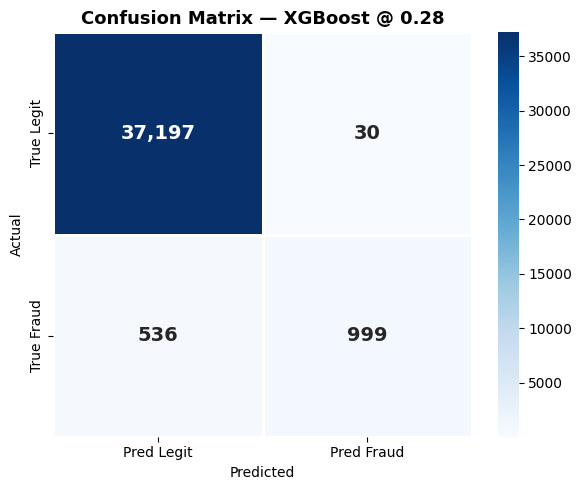

In [31]:
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=ax,
            xticklabels=["Pred Legit", "Pred Fraud"],
            yticklabels=["True Legit", "True Fraud"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix — {best_name} @ {best_thresh:.2f}", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## Score Distribution

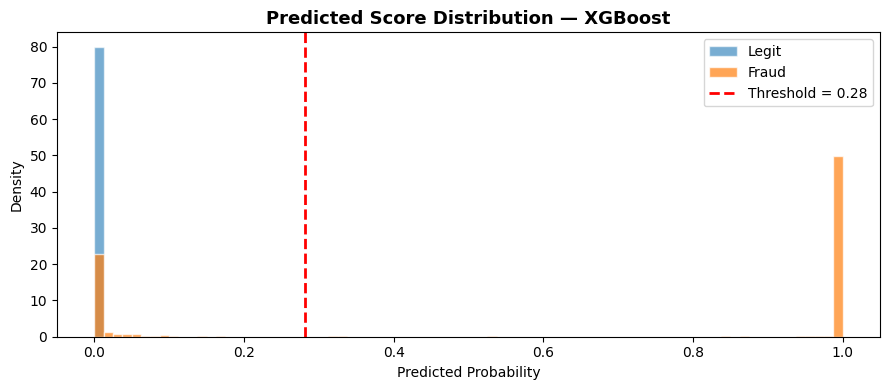

In [32]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(best_res["y_proba"][y_test == 0], bins=80, alpha=0.6,
        density=True, label="Legit", edgecolor="white")
ax.hist(best_res["y_proba"][y_test == 1], bins=80, alpha=0.7,
        density=True, label="Fraud", edgecolor="white")
ax.axvline(best_thresh, color="red", lw=2, ls="--",
           label=f"Threshold = {best_thresh:.2f}")
ax.set_title(f"Predicted Score Distribution — {best_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## F1 vs Threshold

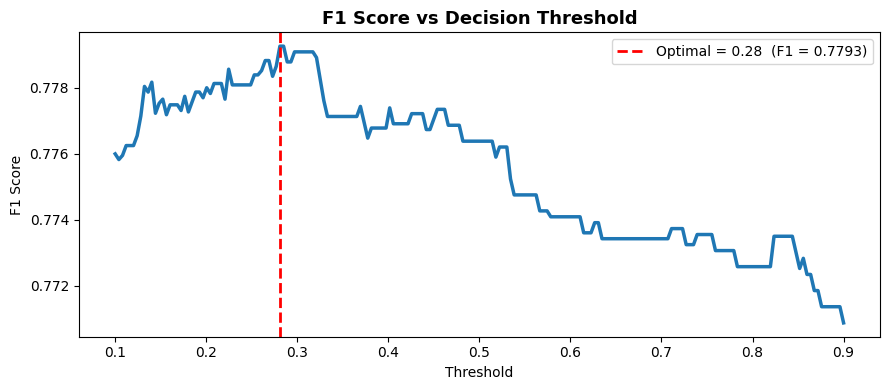

In [33]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores, linewidth=2.5)
ax.axvline(best_thresh, color="red", lw=2, ls="--",
           label=f"Optimal = {best_thresh:.2f}  (F1 = {max(f1_scores):.4f})")
ax.set_title("F1 Score vs Decision Threshold", fontsize=13, fontweight="bold")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.legend()
plt.tight_layout()
plt.show()

# Feature Importance

## Built-in Feature Importance

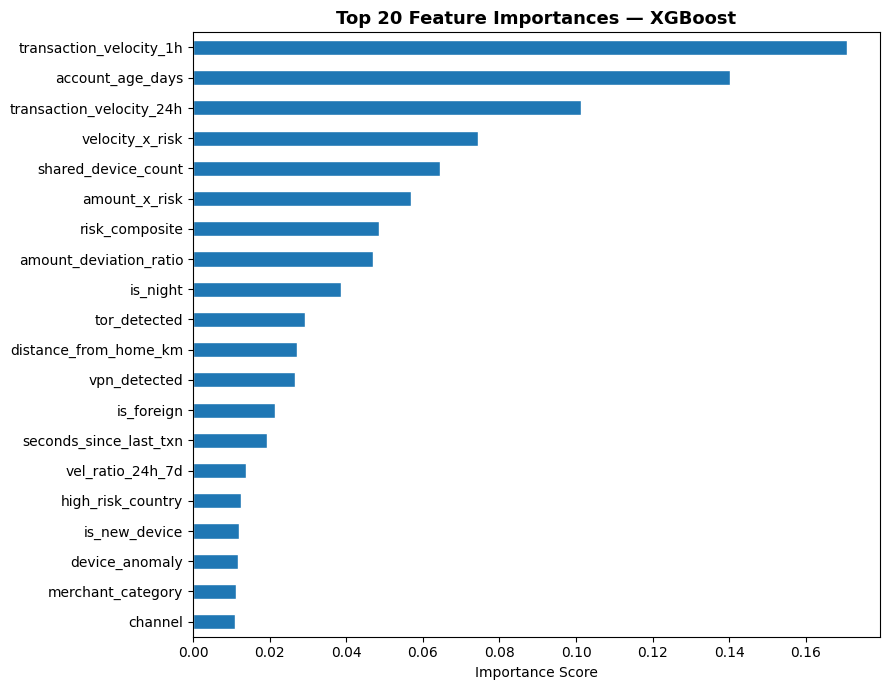

In [34]:
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=X.columns)
    fi = fi.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    fi.sort_values().plot(kind="barh", ax=ax, edgecolor="white")
    ax.set_title(f"Top 20 Feature Importances — {best_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

## SHAP Values

Computing SHAP values (sample of 2000)...


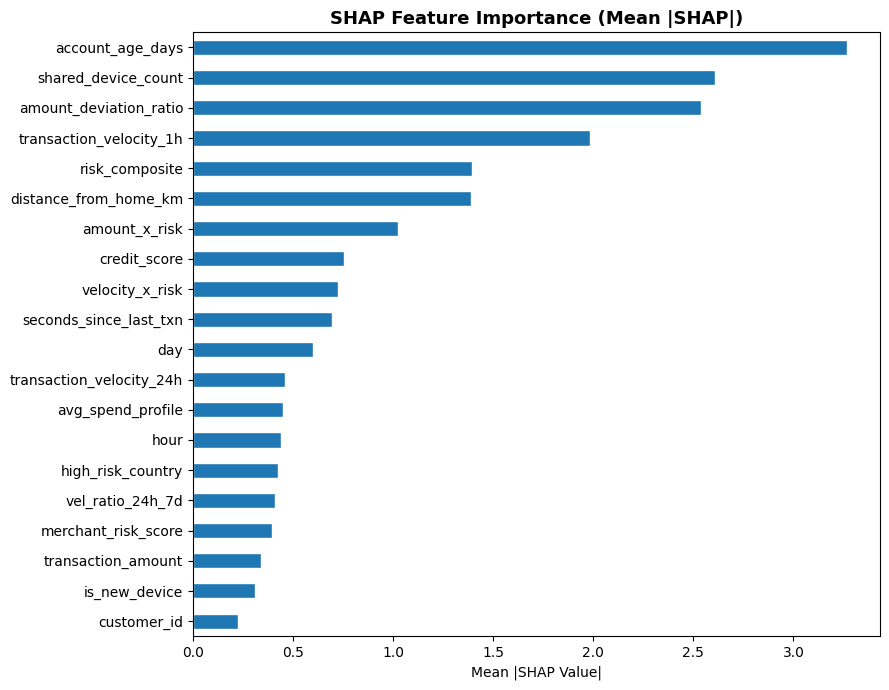

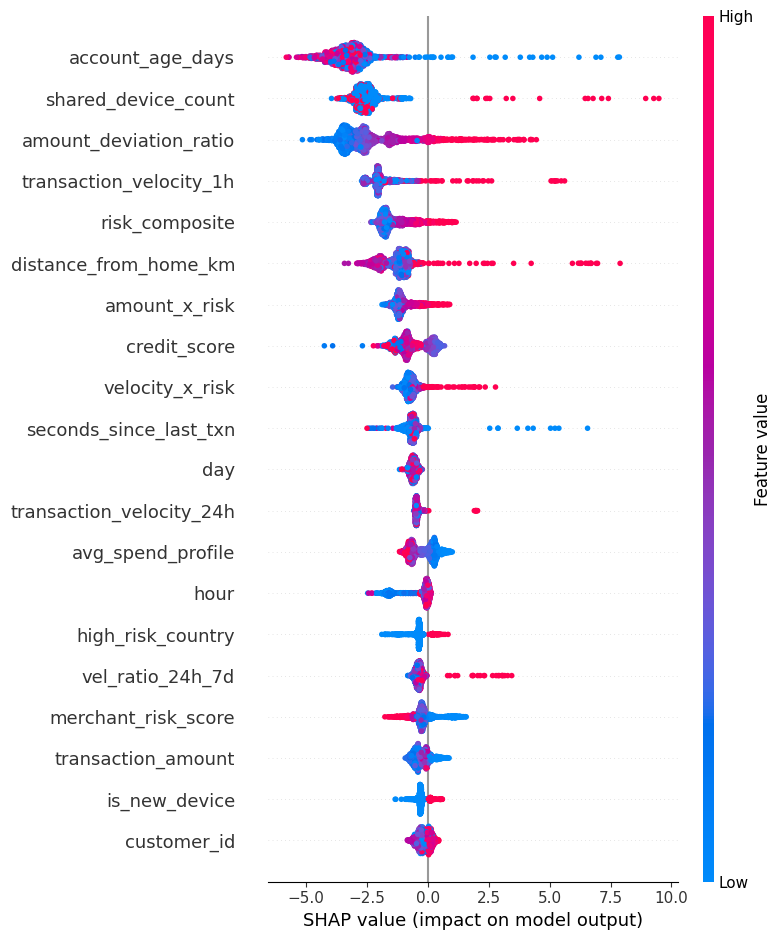

In [35]:
if HAS_SHAP and hasattr(best_model, "feature_importances_"):
    print("Computing SHAP values (sample of 2000)...")
    sample_idx    = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
    X_test_sample = X_test.iloc[sample_idx]

    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sample)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    # SHAP Bar
    shap_mean = pd.Series(np.abs(sv).mean(axis=0), index=X.columns).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(9, 7))
    shap_mean.sort_values().plot(kind="barh", ax=ax, edgecolor="white")
    ax.set_title("SHAP Feature Importance (Mean |SHAP|)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Mean |SHAP Value|")
    plt.tight_layout()
    plt.show()

    # SHAP Beeswarm
    shap.summary_plot(sv, X_test_sample, feature_names=X.columns.tolist(),
                      max_display=20, show=True)

# Save Model

In [36]:
import joblib

joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "fraud_scaler.pkl")
joblib.dump(list(X.columns), "fraud_features.pkl")

['fraud_features.pkl']